In [1]:
# some_file.py
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '../')

import nn_fncs
mat_data = nn_fncs.read_mat_workspace('../Data/motor_model_1e-4_1000.mat') # data sampled at 1e-4s, only 100 trajectories
# mat_data = nn_fncs.read_mat_workspace('../Data/motor_model_1e-4.mat') # data sampled at 1e-4s, only 100 trajectories
# mat_data = nn_fncs.read_mat_workspace('motor_model_data.mat')  # data sampled at 5e-5s

u_signals = mat_data.get('u_signals')
x_motor = mat_data.get('x_motor_out')

print(f'u_signals shape: {u_signals.shape}')  # (num_trajectories, num_time_steps, num_motors)
print(f'x_motor shape: {x_motor.shape}')      # (num_trajectories

u_signals shape: (1000, 30000)
x_motor shape: (1000, 30000, 3)


In [2]:
# Divide data into training and validation sets
from sklearn.preprocessing import StandardScaler

num_trajectories = u_signals.shape[0]
split_ratio = 0.9
split_index = int(num_trajectories * split_ratio)

x_train = x_motor[:split_index, :]
u_train = u_signals[:split_index, :]
x_val = x_motor[split_index:, :]
u_val = u_signals[split_index:, :]

scaler_x = StandardScaler()
scaler_u = StandardScaler()
x_train = scaler_x.fit_transform(x_train.reshape(-1, x_train.shape[-1])).reshape(x_train.shape)
u_train = scaler_u.fit_transform(u_train.reshape(-1, 1)).reshape(u_train.shape)
x_val = scaler_x.transform(x_val.reshape(-1, x_val.shape[-1])).reshape(x_val.shape)
u_val = scaler_u.transform(u_val.reshape(-1, 1)).reshape(u_val.shape)
print(f'x_train shape: {x_train.shape}, u_train shape: {u_train.shape}')
print(f'x_val shape: {x_val.shape}, u_val shape: {u_val.shape}')

x_train shape: (900, 30000, 3), u_train shape: (900, 30000)
x_val shape: (100, 30000, 3), u_val shape: (100, 30000)


In [3]:
# Save scalers
import joblib
joblib.dump(scaler_u, '../Scalers/u_scaler.pkl')
joblib.dump(scaler_x, '../Scalers/x_scaler.pkl')

# Print scaler means and stds
print(f'scaler_x mean: {scaler_x.mean_}, std: {scaler_x.scale_}')
print(f'scaler_u mean: {scaler_u.mean_}, std: {scaler_u.scale_}')

# scaler_x mean: [0.03230177 0.24495376 0.14533393], std: [0.4697081  1.13158322 2.11046949]
# scaler_u mean: [0.38842685], std: [5.64672234]

scaler_x mean: [0.03201231 0.34290865 0.14405855], std: [0.4699203  1.5104491  2.11147021]
scaler_u mean: [0.38495538], std: [5.64930871]


In [4]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F
n_neurons = 32
dropout_rate = 0.1
class MotorModel(nn.Module):
    def __init__(self, u_size=1, x_size=3):  
        super(MotorModel, self).__init__()
        # Fully connected layers
        self.A1 = nn.Linear(x_size, n_neurons) 
        self.A2 = nn.Linear(n_neurons, n_neurons)
        self.A3 = nn.Linear(n_neurons, n_neurons)
        self.A4 = nn.Linear(n_neurons, n_neurons)
        self.outputA = nn.Linear(n_neurons, x_size)

        self.B1 = nn.Linear(u_size, n_neurons) 
        self.B2 = nn.Linear(n_neurons, n_neurons)
        self.outputB = nn.Linear(n_neurons, x_size)
        
        self.dropout = nn.Dropout(dropout_rate)
        

    def forward(self, x0, u):
        
        outA = F.softplus(self.A1(x0))
        outA = self.dropout(F.softplus(self.A2(outA)))
        outA = self.dropout(F.softplus(self.A3(outA)))
        outA = self.dropout(F.softplus(self.A4(outA)))
        outA = self.outputA(outA)

        outB = F.softplus(self.B1(u))
        outB = self.dropout(F.softplus(self.B2(outB)))
        outB = self.outputB(outB)

        x = outA + outB  
        return x

# Create the model
model = MotorModel()

# Print model summary
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')

MotorModel(
  (A1): Linear(in_features=3, out_features=32, bias=True)
  (A2): Linear(in_features=32, out_features=32, bias=True)
  (A3): Linear(in_features=32, out_features=32, bias=True)
  (A4): Linear(in_features=32, out_features=32, bias=True)
  (outputA): Linear(in_features=32, out_features=3, bias=True)
  (B1): Linear(in_features=1, out_features=32, bias=True)
  (B2): Linear(in_features=32, out_features=32, bias=True)
  (outputB): Linear(in_features=32, out_features=3, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
Total parameters: 4614


In [5]:
# One step training
import torch.optim as optim
from torcheval.metrics.functional import mean_squared_error, r2_score

def one_step_training(model, criterion, optimizer, x, u):
    model.train()
    with torch.set_grad_enabled(True):
        # Forward pass
        pred = model(x[:-1], u[:-1])  # Integrate over a small time step
        loss = criterion(pred, x[1:])  # Compare with the next state
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    r2 = r2_score(pred, x[1:])
    return pred, loss, r2


In [6]:
# One step validation

def one_step_validation(model, criterion, x, u):
    model.eval()
    with torch.no_grad():
        # Forward pass
        pred = model(x[:-1], u[:-1])  # Integrate over a small time step
        loss = criterion(pred, x[1:])  # Compare with the next state
    r2 = r2_score(pred, x[1:])
    return pred, loss, r2

In [7]:
# One step evaluation - Unrolled prediction over entire sequence
import torch.optim as optim
from torcheval.metrics.functional import mean_squared_error, r2_score

def one_step_eval(model, x, u):
    t = 0
    predictions = torch.zeros_like(x)
    xk= x[0]
    model.eval()
    with torch.no_grad():
        for i in range(x.shape[0]-1):

            pred = model(xk, u[i])  # Integrate over a small time step
            predictions[i+1] = pred
            xk = pred
    r2 = r2_score(predictions[1:], x[1:])
    mse = mean_squared_error(predictions[1:], x[1:])
    return predictions, mse, r2

In [8]:
# Example training step
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

pred, loss, r2 = one_step_training(model, 
                                   criterion, 
                                   optimizer, 
                                   torch.tensor(x_motor[0,:1000], dtype=torch.float32), 
                                   torch.tensor(u_signals[0,:1000], dtype=torch.float32).unsqueeze(-1))
                                   

print(f'Loss: {loss.item()}, R2: {r2.item()}')

Loss: 0.16818712651729584, R2: -268.7074890136719


In [9]:
# Example validation step
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model.to(device)
val_pred, val_loss, val_r2 = one_step_validation(model, 
                                                 criterion, 
                                                 torch.tensor(x_val[0,:1000], dtype=torch.float32).to(device), 
                                                 torch.tensor(u_val[0,:1000], dtype=torch.float32).unsqueeze(-1).to(device))
print(f'Validation Loss: {val_loss.item()}, Validation R2: {val_r2.item()}')

Validation Loss: 0.20662616193294525, Validation R2: -90.1181640625


In [10]:
# Example evaluation step
eval_pred, eval_mse, eval_r2 = one_step_eval(model,
                                               torch.tensor(x_val[0,:1000], dtype=torch.float32).to(device),
                                               torch.tensor(u_val[0,:1000], dtype=torch.float32).unsqueeze(-1).to(device))
print(f'Evaluation MSE: {eval_mse.item()}, Evaluation R2: {eval_r2.item()}')


Evaluation MSE: 0.20569446682929993, Evaluation R2: -88.81901550292969


In [11]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F
n_neurons = 32
dropout_rate = 0.1
class MotorModelResidual(nn.Module):
    def __init__(self, u_size=1, x_size=3):  
        super(MotorModelResidual, self).__init__()
        # Fully connected layers
        self.A1 = nn.Linear(x_size, n_neurons) 
        self.A2 = nn.Linear(n_neurons, n_neurons)
        self.A3 = nn.Linear(n_neurons, n_neurons)
        self.A4 = nn.Linear(n_neurons, n_neurons)
        self.outputA = nn.Linear(n_neurons, x_size)

        self.B1 = nn.Linear(u_size, n_neurons) 
        self.B2 = nn.Linear(n_neurons, n_neurons)
        self.outputB = nn.Linear(n_neurons, x_size)
        
        self.dropout = nn.Dropout(dropout_rate)
        

    def forward(self, x0, u):
        
        outA = F.softplus(self.A1(x0))
        outA = self.dropout(F.softplus(self.A2(outA)))
        outA = self.dropout(F.softplus(self.A3(outA)))
        outA = self.dropout(F.softplus(self.A4(outA)))
        outA = self.outputA(outA)

        outB = F.softplus(self.B1(u))
        outB = self.dropout(F.softplus(self.B2(outB)))
        outB = self.outputB(outB)

        x = x0 + outA + outB  
        return x

# Create the model
model = MotorModelResidual()

# Print model summary
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')

MotorModelResidual(
  (A1): Linear(in_features=3, out_features=32, bias=True)
  (A2): Linear(in_features=32, out_features=32, bias=True)
  (A3): Linear(in_features=32, out_features=32, bias=True)
  (A4): Linear(in_features=32, out_features=32, bias=True)
  (outputA): Linear(in_features=32, out_features=3, bias=True)
  (B1): Linear(in_features=1, out_features=32, bias=True)
  (B2): Linear(in_features=32, out_features=32, bias=True)
  (outputB): Linear(in_features=32, out_features=3, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
Total parameters: 4614


In [12]:
from random import randint
from tqdm import tqdm 
# Complete training loop

# Load last best model
# model.load_state_dict(torch.load('best_motor_model.pt'))


num_epochs = 10
mini_trajectory_length = 100
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
u_tensor = torch.from_numpy(u_signals).type(torch.float32).to(device)
x_tensor = torch.from_numpy(x_motor).type(torch.float32).to(device)
u_val_tensor = torch.from_numpy(u_val).type(torch.float32).to(device)
x_val_tensor = torch.from_numpy(x_val).type(torch.float32).to(device)
best_val_r2 = -float('inf')

history = {'train_loss': [], 'train_r2': [], 'val_loss': [], 'val_r2': []}
with tqdm(total=num_epochs, desc="Training Progress") as pbar:
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        epoch_r2 = 0.0
        # for i in range(5):
        #     id = randint(0,u_signals.shape[0]-1)
        for id in range(u_signals.shape[0]):
            u_traj = u_tensor[id]
            x_traj = x_tensor[id]
            for start in range(0, u_traj.shape[0]-mini_trajectory_length, mini_trajectory_length):
                end = start + mini_trajectory_length
                u_traj_segment = u_traj[start:end]
                x_traj_segment = x_traj[start:end]
                pred, loss, r2 = one_step_training(model, criterion, optimizer, x_traj_segment, u_traj_segment.unsqueeze(-1))
                epoch_loss += loss.item()*mini_trajectory_length
                epoch_r2 += r2.item()*mini_trajectory_length

        epoch_loss /= (u_signals.shape[0]*u_signals.shape[1])
        epoch_r2 /= (u_signals.shape[0]*u_signals.shape[1])
        history['train_loss'].append(epoch_loss)
        history['train_r2'].append(epoch_r2)

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6e}, R2: {epoch_r2:.6e}')
        val_epoch_loss = 0.0
        val_epoch_r2 = 0.0
        # Validation
        for id in range(x_val_tensor.shape[0]):
            val_pred, val_loss, val_r2 = one_step_validation(model, criterion, x_val_tensor[id], u_val_tensor[id].unsqueeze(-1))
            # val_pred, val_loss, val_r2 = one_step_eval(model, x_val_tensor[id], u_val_tensor[id].unsqueeze(-1))
            val_epoch_loss += val_loss.item()
            val_epoch_r2 += val_r2.item()
        val_epoch_loss /= (x_val.shape[0])
        val_epoch_r2 /= (x_val.shape[0])
        if val_epoch_r2 > best_val_r2:
            best_val_r2 = val_epoch_r2
            # torch.save(model.state_dict(), 'best_motor_model.pt')
            nn_fncs.save_best_model(model, val_epoch_r2, -float('inf'), directory=".", model_name="resnet_std")
        print(f'Validation Loss: {val_epoch_loss:.6e}, Validation R2: {val_epoch_r2:.6e}')
        history['val_loss'].append(val_epoch_loss)
        history['val_r2'].append(val_epoch_r2)
        pbar.update(1)

Training Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch [1/10], Loss: 1.200017e-04, R2: nan


Training Progress:  10%|█         | 1/10 [17:23<2:36:33, 1043.73s/it]

Validation Loss: 1.178620e-02, Validation R2: 4.792234e-01


Training Progress:  20%|██        | 2/10 [34:25<2:17:24, 1030.54s/it]

...

Training Progress:  90%|█████████ | 9/10 [2:40:21<18:00, 1080.35s/it]

Epoch [9/10], Loss: 6.622897e-05, R2: nan
Validation Loss: 3.915076e-02, Validation R2: -1.732212e+00


Training Progress: 100%|██████████| 10/10 [2:58:32<00:00, 1083.59s/it]

Epoch [10/10], Loss: 1.601067e-04, R2: nan
Validation Loss: 2.152936e-02, Validation R2: -1.410849e-01


Training Progress: 100%|██████████| 10/10 [2:58:32<00:00, 1071.26s/it]


Loss: 855.1551513671875, R2: -1627.83544921875
pred shape: torch.Size([30000, 3])
x_motor shape: (30000, 3)


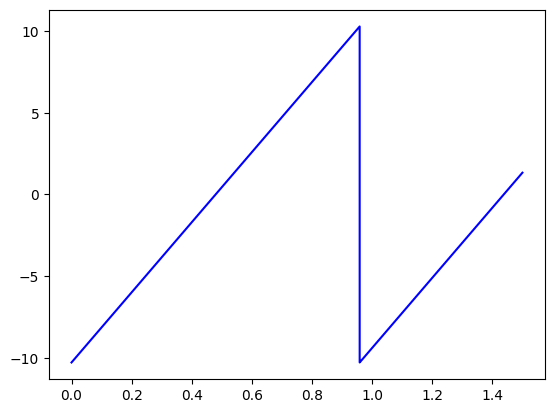

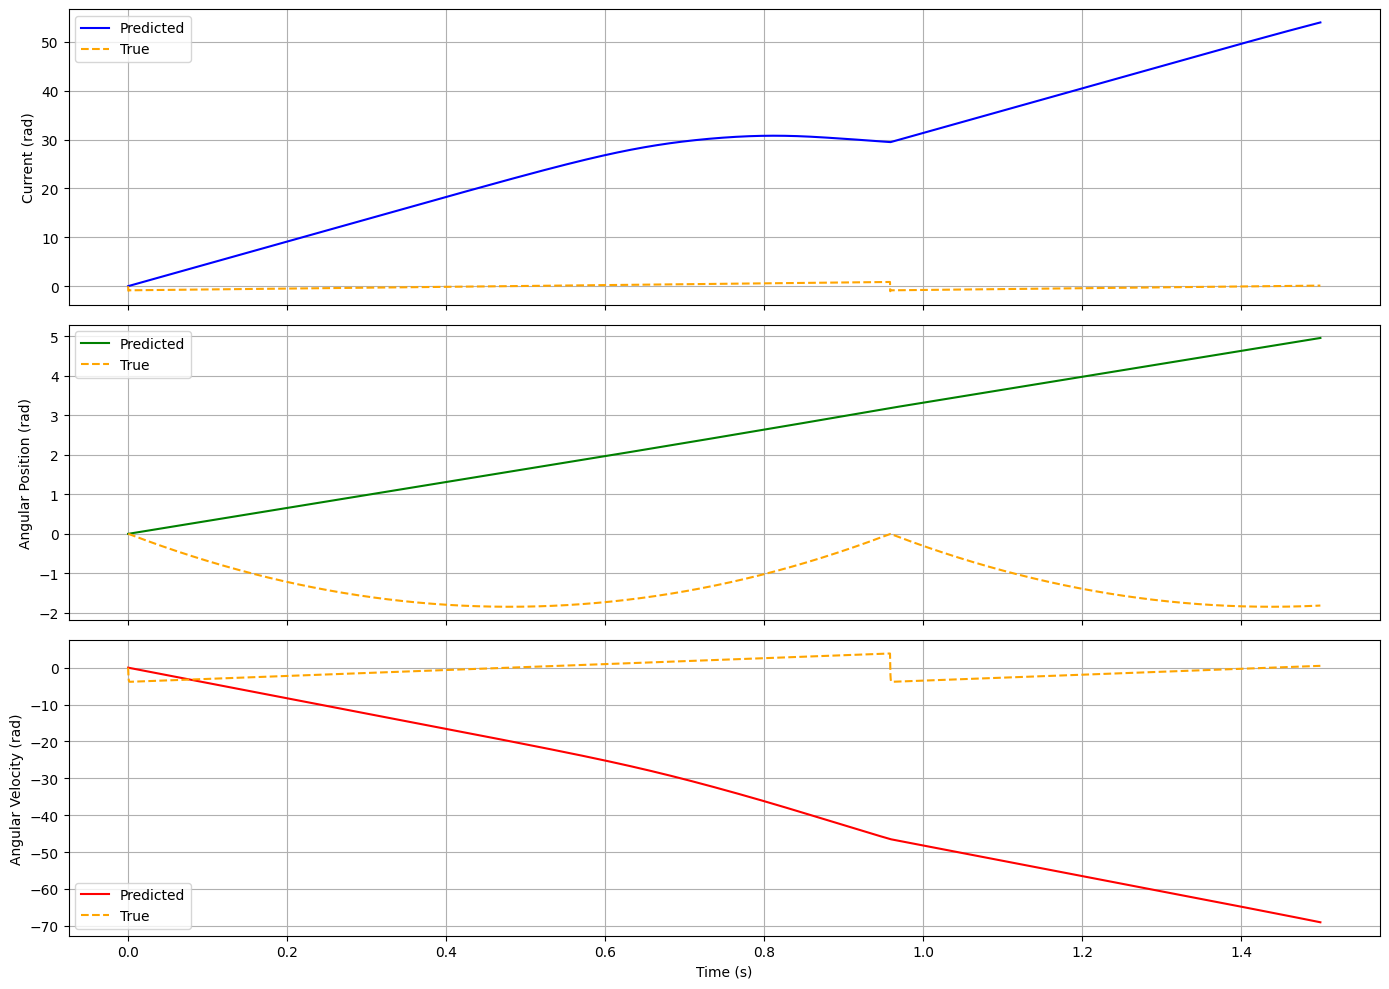

In [13]:
# Choose a random test trajectory
from random import randint  
id = randint(0,u_signals.shape[0]-1)
model = model.to(device)
pred, mse, r2 = one_step_eval(model, torch.tensor(x_motor[id,:], dtype=torch.float32).to(device),
                                torch.tensor(u_signals[id,:], dtype=torch.float32).to(device).unsqueeze(-1))
print(f'Loss: {mse.item()}, R2: {r2.item()}')
# Shapes
print(f'pred shape: {pred.shape}')  # (num_states,)
print(f'x_motor shape: {x_motor[id,:].shape}')  # (num_time_steps, num_states)

import matplotlib.pyplot as plt

# Prepare time axis
time = torch.arange(0, pred.shape[0]*5e-5, 5e-5)
#Plot u signals
plt.plot(time.cpu(), u_signals[id, :], label='Current', color='blue')
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
labels = ['Current', 'Angular Position', 'Angular Velocity']
colors = ['blue', 'green', 'red']

for i in range(3):
    axs[i].plot(time.cpu(), pred[:, i].cpu().detach().numpy(), label='Predicted', color=colors[i])
    axs[i].plot(time.cpu(), x_motor[id, :, i], label='True', color='orange', linestyle='--')
    axs[i].set_ylabel(f'{labels[i]} (rad)')
    axs[i].legend()
    axs[i].grid(True)

axs[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [14]:
# Save final model
torch.save(model.state_dict(), "resnet_time_stepper_ABmats_v1_retrained.pth")

In [15]:
# Runge-Kutta 4th order method for ODE solving
def rk4_step_func(func, x0, dt, u):
    k1 = func(x0, u)
    k1 = k1*dt

    k2 = func(x0+k1/2, u)
    k2 = k2*dt

    k3 = func(x0+k2/2, u)
    k3 = k3*dt

    k4 = func(x0+k3, u)
    k4 = k4*dt

    return x0 + (k1 + 2 * (k2 + k3) + k4) / 6

In [16]:
model = MotorModel()
dt = 1e-4


In [17]:
# One step training
import torch.optim as optim
from torcheval.metrics.functional import mean_squared_error, r2_score
from scipy.integrate import odeint

def one_step_training_rk4(model, criterion, optimizer, x, u, dt):
    t = 0
    loss = 0.0
    model.train()
    with torch.set_grad_enabled(True):
        # Forward pass
        pred = rk4_step_func(model, x[:-1], dt, u[:-1])  # Integrate over a small time step
        loss = criterion(pred, x[1:])
        # Backward and optimize
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    r2 = r2_score(pred, x[1:])
    return pred, loss, r2

In [18]:
from random import randint
from tqdm import tqdm 
# Complete training loop

num_epochs = 10
mini_trajectory_length = 100
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
u_tensor = torch.from_numpy(u_signals).type(torch.float32).to(device)
x_tensor = torch.from_numpy(x_motor).type(torch.float32).to(device)
with tqdm(total=num_epochs, desc="Training Progress") as pbar:
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        epoch_r2 = 0.0
        for id in range(u_signals.shape[0]):
            u_traj = u_tensor[id]
            x_traj = x_tensor[id]
            for start in range(0, u_traj.shape[0]-mini_trajectory_length, mini_trajectory_length):
                end = start + mini_trajectory_length
                u_traj_segment = u_traj[start:end]
                x_traj_segment = x_traj[start:end]
                pred, loss, r2 = one_step_training_rk4(model, criterion, optimizer, 
                                                       x_traj_segment, u_traj_segment.unsqueeze(-1), dt)
                epoch_loss += loss.item()*mini_trajectory_length
                epoch_r2 += r2.item()*mini_trajectory_length

        epoch_loss /= (u_signals.shape[0]*u_signals.shape[1])
        epoch_r2 /= (u_signals.shape[0]*u_signals.shape[1])

        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6e}, R2: {epoch_r2:.6e}')
        pbar.update(1)

Training Progress:  10%|█         | 1/10 [51:33<7:43:59, 3093.32s/it]

Epoch [1/10], Loss: 2.527882e-05, R2: -inf


Training Progress:  20%|██        | 2/10 [2:01:21<8:18:20, 3737.54s/it]

Epoch [2/10], Loss: 1.952735e-05, R2: -inf


Training Progress:  30%|███       | 3/10 [3:32:22<8:47:49, 4524.18s/it]

...

Epoch [8/10], Loss: 1.797410e-05, R2: -inf


Training Progress:  90%|█████████ | 9/10 [8:51:14<56:08, 3368.48s/it]  

Epoch [9/10], Loss: 1.789884e-05, R2: -inf


Training Progress: 100%|██████████| 10/10 [9:50:57<00:00, 3545.72s/it]

Epoch [10/10], Loss: 1.795032e-05, R2: -inf


In [19]:
# Save final model
torch.save(model.state_dict(), "node_ABmats_v2.pth") # Reduction in MSE - sum

In [23]:
# One step evaluation
import torch.optim as optim
from torcheval.metrics.functional import mean_squared_error, r2_score

def one_step_eval_rk4(model, x,u,dt):
    t = 0
    predictions = torch.zeros_like(x)
    model.eval()
    xk = x[0]
    torch.no_grad()
    for i in range(x.shape[0]-1):

        pred = rk4_step_func(model, xk, dt, u[i].unsqueeze(-1) )  # Integrate over a small time step
        predictions[i+1] = pred
        xk = pred
        # Backward and optimize
    r2 = r2_score(predictions[1:], x[1:])
    mse = mean_squared_error(predictions[1:], x[1:])
    return predictions, mse, r2

In [34]:
# Choose a random test trajectory
from random import randint  
test_size = 15000
model = MotorModel()
dt = 1e-4
loaded_state_dict = torch.load("node_ABmats_v2.pth")
model.load_state_dict(loaded_state_dict)

id = randint(0,u_signals.shape[0]-1)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

pred, mse, r2 = one_step_eval_rk4(model, torch.tensor(x_motor[id,:test_size], dtype=torch.float32).to(device),
                                torch.tensor(u_signals[id,:test_size], dtype=torch.float32).to(device).unsqueeze(-1),dt=dt)
print(f'Loss: {mse.item()}, R2: {r2.item()}')
# Shapes
print(f'pred shape: {pred.shape}')  # (num_states,)
print(f'x_motor shape: {x_motor[id,:test_size].shape}')  # (num_time_steps, num_states)

Loss: 2.9889228343963623, R2: -37.14793395996094
pred shape: torch.Size([15000, 3])
x_motor shape: (15000, 3)


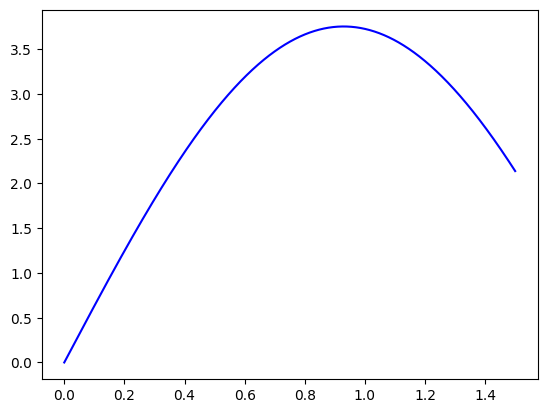

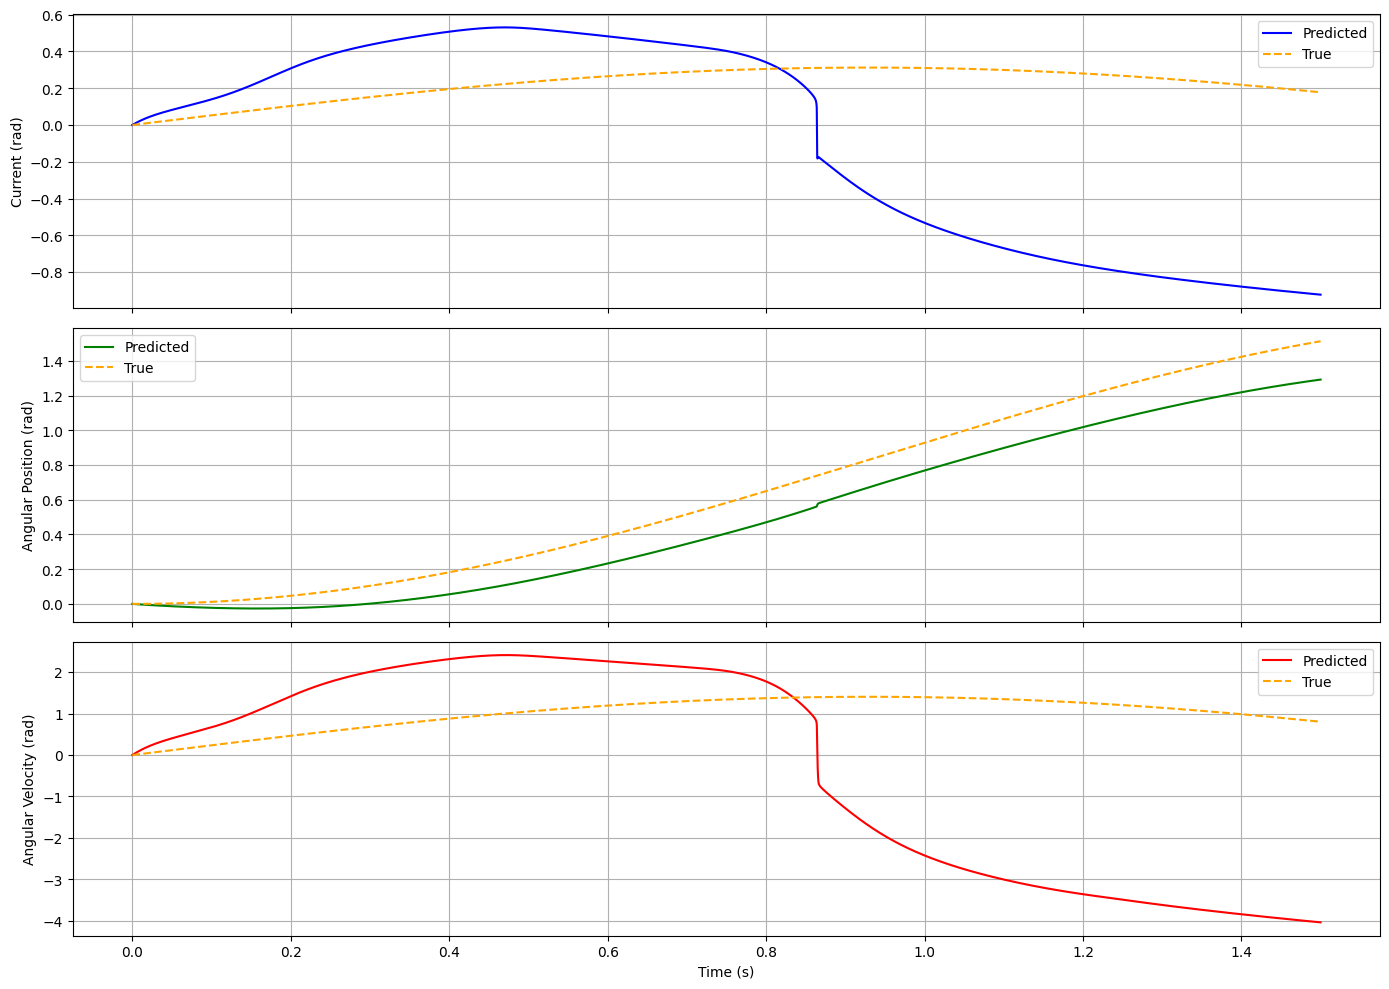

In [35]:

import matplotlib.pyplot as plt

# Prepare time axis
time = torch.arange(0, pred.shape[0]*dt, dt)[:test_size]
#Plot u signals
plt.plot(time.cpu(), u_signals[id, :test_size], label='Current', color='blue')
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
labels = ['Current', 'Angular Position', 'Angular Velocity']
colors = ['blue', 'green', 'red']

for i in range(3):
    axs[i].plot(time.cpu()[:test_size], pred[:test_size, i].cpu().detach().numpy(), label='Predicted', color=colors[i])
    axs[i].plot(time.cpu()[:test_size], x_motor[id, :test_size, i], label='True', color='orange', linestyle='--')
    axs[i].set_ylabel(f'{labels[i]} (rad)')
    axs[i].legend()
    axs[i].grid(True)

axs[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()